# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 


In [1]:
from scapy.all import rdpcap
from netml.pparser.parser import PCAP

PCAP_FILE = "../notebooks/data/netflix.pcap"

packets = rdpcap(PCAP_FILE)
print(len(packets), "packets")

# netml groups packets into 5-tuple flows, then uses a "split interval" as an
# idle timeout: a flow is cut into subflows wherever two consecutive packets are
# more than the interval apart. With q_interval=0.9 that interval is the 90th
# percentile of the flow durations, so a gap has to be longer than 90% of whole
# flows before it counts as a split. Subflows with fewer than flow_ptks_thres
# packets are discarded, and pc_all.flows is what remains after both steps.
pc_all = PCAP(PCAP_FILE, flow_ptks_thres=2, verbose=0, random_state=42)
pc_all.pcap2flows(q_interval=0.9)

print(f"{len(pc_all.flows)} flows with at least {pc_all.flow_ptks_thres} packets")
print(f"computed split interval: {pc_all.interval:.2f} s "
      f"(90th percentile of {len(pc_all.flow_durations)} raw flow durations)")
packets[0].summary()

141471 packets
184 flows with at least 2 packets
computed split interval: 277.87 s (90th percentile of 184 raw flow durations)


'Ether / IP / UDP / DNS Qry "b\'fonts.gstatic.com.\'" '

### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [2]:
from scapy.all import IP, TCP, DNS

NF_DOMAINS = ["nflxvideo", "netflix", "nflxso", "nflxext", "nflximg"]

dns = [p for p in packets if p.haslayer(DNS) and IP in p]
CLIENT = next(p[IP].src for p in dns if p[DNS].qr == 0)   # whoever sends the queries

# transaction id -> queried name, for the Netflix lookups only
nf_queries = {p[DNS].id: p[DNS].qd.qname.decode().rstrip(".")
              for p in dns
              if p[DNS].qr == 0 and p[DNS].qd
              and any(d in p[DNS].qd.qname.decode() for d in NF_DOMAINS)}

# The DNS responses in this trace carry no question section, so the only way
# back from a response to the domain it answered is the transaction id.
netflix_ips, video_ips = set(), set()
for p in dns:
    d = p[DNS]
    if d.qr != 1 or d.id not in nf_queries:
        continue
    for i in range(d.ancount):
        rr = d.an[i]
        if rr.type != 1:                      # A records only
            continue
        netflix_ips.add(rr.rdata)
        if "nflxvideo" in nf_queries[d.id]:   # OCA servers, i.e. the video itself
            video_ips.add(rr.rdata)

netflix = [p for p in packets
           if IP in p and (p[IP].src in netflix_ips or p[IP].dst in netflix_ips)]

print("client:", CLIENT)
print(f"{len(netflix_ips)} Netflix IPs, {len(video_ips)} of them video servers")
print(f"{len(netflix):,} of {len(packets):,} packets are Netflix")

client: 192.168.43.72
16 Netflix IPs, 7 of them video servers
140,472 of 141,471 packets are Netflix


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [3]:
import pandas as pd
from scapy.all import wrpcap
from netml.pparser.parser import PCAP

wrpcap("netflix_only.pcap", netflix)          # netml reads a file, not a packet list

pc = PCAP("netflix_only.pcap", flow_ptks_thres=2, verbose=0, random_state=42)
pc.pcap2flows(q_interval=0.9)
pc.flow2features("STATS", fft=False, header=False)

STATS_COLS = ["duration", "pkts_rate", "bytes_rate", "size_mean", "size_std",
              "size_q1", "size_median", "size_q3", "size_min", "size_max",
              "num_pkts", "num_bytes"]
stats = pd.DataFrame(pc.features, columns=STATS_COLS)

# This capture stored only the first 200 bytes of each packet, so netml's size_*
# and *_bytes columns -- which measure the *captured* length -- top out at 200 and
# badly understate the real traffic. The IP header's length field still records
# the true on-wire size, so recompute the byte features from that.
# pc.flows is row-aligned with pc.features, so this needs no join.
sizes = [[p[IP].len for p in pkts] for _, pkts in pc.flows]
stats["wire_bytes"] = [sum(s) for s in sizes]
stats["wire_size_mean"] = [sum(s) / len(s) for s in sizes]
stats["wire_size_max"] = [max(s) for s in sizes]
stats["wire_bytes_rate"] = (stats["wire_bytes"] / stats["duration"]).where(
    stats["duration"] > 0, 0.0)

stats.insert(0, "server", [f[1] if f[0] == CLIENT else f[0] for f in pc.fids])
stats.insert(1, "direction", ["down" if f[1] == CLIENT else "up" for f in pc.fids])

print(stats.shape)
stats.sort_values("wire_bytes", ascending=False).head()

(138, 18)


,server,direction,duration,pkts_rate,bytes_rate,size_mean,size_std,size_q1,size_median,size_q3,size_min,size_max,num_pkts,num_bytes,wire_bytes,wire_size_mean,wire_size_max,wire_bytes_rate
108,198.38.120.166,down,432.092108,80.767502,16148.850837,199.942434,2.657963,200.0,200.0,200.0,66.0,200.0,34899.0,6977791.0,52230863,1496.629216,1500,120879.002490
119,198.38.120.166,down,277.847615,75.059129,14988.399306,199.687893,6.177350,200.0,200.0,200.0,66.0,200.0,20855.0,4164491.0,31066465,1489.641093,1500,111811.163107
91,198.38.120.166,down,210.397020,78.984008,15779.629381,199.782585,5.125137,200.0,200.0,200.0,66.0,200.0,16618.0,3319987.0,24780534,1491.186304,1500,117779.871540
109,198.38.120.166,down,49.454091,143.688820,28626.731769,199.227273,9.730783,200.0,200.0,200.0,66.0,200.0,7106.0,1415709.0,10551241,1484.835491,1500,213354.259906
90,198.38.120.164,down,114.381312,13.839673,2744.093373,198.277322,14.364958,200.0,200.0,200.0,66.0,200.0,1583.0,313873.0,2298510,1451.996210,1500,20095.153325


**Write a brief justification for the features that you have chosen.**

The goal is to infer video quality from traffice alone (quality is driven by bitrate), so a higher resolution stram has to move mroe bytes per second than a lower one. So the core features I chose are the ones that measure volume and rate (such as, bytes_rate, num_bytes, pkts_rate, and num_pkts). Those features capture how much data a flow carries and how fast, as well as the duration that puts those counts into context. 

This capture stored only the first 200 bytes of each packet, so netml's size and byte features measure the captured length and saturate at 200. I recomputed wire_bytes, wire_size_mean, wire_size_max and wire_bytes_rate from the IPheader's total-length field, which records the true on-wire size. 

Also, I added server and direction to each flow. Noting that video travels downstream from the content servers, while the upstream only carries requests and ACKs, so direction identifies which flows can carry the quality signal. 

Lastly, I used netml's STATS feature rather than the fft or SAMP families because they are compact and directly interpretable to understand the properties that bitrate changes. 

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [4]:
WINDOW = 10  # seconds -- the interval Part 3 asks us to predict at

# Downstream packets from the video (OCA) servers only. The API and image
# servers show the same request/response pattern but carry no video, so
# including them would roughly double the segment count on 1% of the bytes.
rows = [{"t": float(p.time),
         "src": p[IP].src,
         "payload": p[IP].len - 4 * p[IP].ihl - 4 * p[TCP].dataofs}
        for p in netflix
        if TCP in p and p[IP].dst == CLIENT and p[IP].src in video_ips]

down = pd.DataFrame(rows).sort_values("t").reset_index(drop=True)
down["t"] -= down["t"].min()
down["window"] = (down["t"] // WINDOW).astype(int)

# A segment download is a run of packets carrying data, separated by a packet
# with a zero-byte payload. Group by server so interleaved flows don't merge.
is_data = down["payload"] > 0
down["seg_start"] = is_data & ~is_data.groupby(down["src"]).shift(fill_value=False)

feat = down.groupby("window").agg(
    down_bytes=("payload", "sum"),
    down_pkts=("payload", "size"),
    segments=("seg_start", "sum"),
).reindex(range(int(down["window"].max()) + 1), fill_value=0)

feat["throughput_bps"] = feat["down_bytes"] * 8 / WINDOW
feat["segment_rate"] = feat["segments"] / WINDOW

print(f"{int(feat['segments'].sum())} video segments over {len(feat)} windows "
      f"({feat['segments'].mean():.2f} per window)")
feat.head(12)

90 video segments over 50 windows (1.80 per window)


,down_bytes,down_pkts,segments,throughput_bps,segment_rate
window,,,,,
0,64015,116,12,51212.0,1.2
1,102732,116,3,82185.6,0.3
2,386585,280,2,309268.0,0.2
3,311218,217,0,248974.4,0.0
4,388064,268,0,310451.2,0.0
5,3532183,2497,9,2825746.4,0.9
6,17771859,12355,4,14217487.2,0.4
7,16503923,11448,1,13203138.4,0.1
8,769363,537,2,615490.4,0.2


## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files. They are hosted in the course data repository on GitHub, [noise-courses/data](https://github.com/noise-courses/data), in the `video-qoe/` directory. Download them by running the code below:

```
!curl -sSLO https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/netflix_session.pkl
!curl -sSLO https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
!xz -d video_dataset.pkl.xz
```

(`curl` ships with macOS; `wget` does not. On Linux either works, and `wget <url>`
is the direct equivalent of `curl -sSLO <url>`.)

The dataset is stored xz-compressed in the repository (61 MB compressed, about 265 MB uncompressed), so the last line decompresses it. If `xz` is not available on your system, you can decompress it in Python instead:

```python
import lzma, shutil
with lzma.open('video_dataset.pkl.xz') as f_in, open('video_dataset.pkl', 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
```

A smaller Netflix-only dataset (`netflix_dataset.pkl.xz`, 52,279 samples with 251 features) is available in the same directory and may be used instead of the multi-service `video_dataset.pkl` (204,713 samples with 170 features).

**Backup (Google Drive):** If GitHub is unavailable, the Netflix-only dataset is also mirrored on Google Drive:

```
!gdown 'https://drive.google.com/uc?id=1iI1tos08p9FJBI-ADR9b_iFObWRwXANX' -O netflix_dataset.pkl
```

Note: the Google Drive links that previously appeared here (file IDs `1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS` and `1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI`) no longer work.

### Load the File

Load the video dataset pickle file.

In [5]:
import pandas as pd

df = pd.read_pickle("video_dataset.pkl")

print(df.shape)
df.head()


(204713, 170)


,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_all_prev_down_chunk_iat_50,...,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
0,148947.1,43473.0,185098.0,361832.3,461040.2,539882,4380,185126.042201,1.548881e+09,161.5,...,19684.624818,57.462837,985.136457,0,4,0.0,0,0.108730,0.557937,netflix
1,91984.2,101882.0,122323.0,159843.4,181011.8,196778,24498,62449.107359,1.548881e+09,361.0,...,8183.942278,71.011784,310.123152,0,1,0.0,0,0.116865,0.549802,netflix
2,147725.0,111373.0,224157.0,286280.0,325845.8,396800,24498,134268.559725,1.548881e+09,337.0,...,7087.849223,85.198800,149.669427,0,0,0.0,0,0.126852,0.539815,netflix
3,246420.6,297522.0,330737.5,361030.7,378404.0,396800,24498,127394.372454,1.548881e+09,399.0,...,56963.445789,109.397055,14006.713648,0,1,0.0,0,0.186111,0.480556,netflix
4,336681.0,354461.0,399719.5,409866.3,414060.0,438000,198238,79844.367998,1.548881e+09,414.0,...,10988.579443,122.132897,13261.305817,0,0,0.0,0,0.194444,0.472222,netflix


### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [6]:
VALID_RESOLUTIONS = [240, 360, 480, 720, 1080]

df = df[df["resolution"].isin(VALID_RESOLUTIONS)].copy()

print(df.shape)
df["resolution"].value_counts().sort_index()


(200063, 170)


resolution
240.0     45538
360.0     31713
480.0     73056
720.0     37986
1080.0    11770
Name: count, dtype: int64

### Set Aside One Session for Part 3

Part 3 asks for a *preprocessed Netflix session* the model has never seen. The file the assignment provides for that (`netflix_session.pkl`) is unusable: the copy in the course data repository is a saved Google "Error 404" HTML page, not a pickle, so `pd.read_pickle` fails on it with `invalid load key, '<'`.

The dataset we already have contains 1,000 complete Netflix sessions in exactly the format that file would have had (the same features, one row per 10-second window, ordered by `relative_timestamp`). So we carve one session out here and keep it for Part 3.

This has to happen **before** the columns are dropped and **before** the train-test split. `session_id` is what lets us pick a session, and it is about to be dropped. More importantly, if this session's windows stay in `df`, they end up in `X_train`, the model learns from them, and the Part 3 "prediction" is really recall. Because the model is refit from `df`, every cell from here to the end of Part 2 needs to be re-run after this one.

In [7]:
# Pick the session deterministically (first in sorted order) from those of typical
# length whose resolution actually changes, so the Part 3 plot shows the adaptive
# bitrate ramp rather than a flat line. This is a criterion about the *plot*, not
# about which session the model does well on -- choosing on accuracy would be cheating.
nf = df[df["service"] == "netflix"]
per_session = nf.groupby("session_id").agg(
    windows=("resolution", "size"),
    n_res=("resolution", "nunique"))
candidates = per_session[per_session["windows"].between(40, 60) & (per_session["n_res"] >= 4)]
HOLDOUT_ID = candidates.index[0]

# holdout keeps *all* columns, including relative_timestamp (the x-axis of the
# Part 3 plot) and resolution (the ground truth we compare against).
holdout = df[df["session_id"] == HOLDOUT_ID].sort_values("relative_timestamp").copy()
df = df[df["session_id"] != HOLDOUT_ID]

print(f"{len(candidates)} candidate sessions; holding out {HOLDOUT_ID}")
print(f"{len(holdout)} windows, resolutions seen: "
      f"{sorted(holdout['resolution'].astype(int).unique().tolist())}")
print("remaining training rows:", len(df))

33 candidate sessions; holding out 1271251554017ecbb0e8ba991ce1548c
59 windows, resolutions seen: [240, 480, 720, 1080]
remaining training rows: 200004


BACK TO PART 2: Clean the File

2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [8]:
DROP_COLS = [
    "home_id", "session_id", "video_id",   # identifiers of the experiment, not properties of the traffic
    "service",                             # which platform -- a label we attach, not something measured
    "index", "absolute_timestamp",         # row bookkeeping and wall-clock time of the capture
    "relative_timestamp", "video_position" # where we are in the session / video -- player state, not traffic
]

df = df.drop(columns=DROP_COLS)

print(df.shape)


(200004, 162)


**Briefly explain why you removed those columns.**

I dropped columns that were identifiers such as home_id, session_id, and video_id. These are just names for which experiment a row came from and nothing about what the traffic looked like. We want to learn about the traffic-to-resolution relationship. I also dropped bookkeeping columns like index, and absolute_timestamp. A row counter and a timestamp carries no information about video quality. The other columns that I dropped were relative_timestamp and video_position. These are information regarding the video player's own state, like how far into the session and into the video we are. They are correlated with resolution but the whole point of this ML is to infer quality without access to the player, and a pcap doesn't contain that information either. 

Dropping "service" was more of a judgement call because a model can learn that Twitch and Netflix behave differently. I dropped it because it is a catagorical string rather than a traffic measurement. Also, a model trained on network features alone is the more honest test of whether traffic features carry the signal. 

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="resolution")
y = df["resolution"].astype(int)

# stratify keeps the 5 resolution classes in the same proportions in train and test,
# which matters because 480p has ~6x as many samples as 1080p
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("features:", X.shape[1])
print("train:", len(X_train), " test:", len(X_test))


features: 161
train: 160003  test: 40001


### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("baseline test accuracy:", round(accuracy_score(y_test, rf.predict(X_test)), 4))


baseline test accuracy: 0.9556


### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [20, None],
    "min_samples_leaf": [1, 5],
}

# f1_macro instead of accuracy so the rare 1080p class counts as much as 480p
search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring="f1_macro", verbose=1)
search.fit(X_train, y_train)

print("best params:", search.best_params_)
print("best CV f1_macro:", round(search.best_score_, 4))

model = search.best_estimator_


Fitting 3 folds for each of 8 candidates, totalling 24 fits
best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
best CV f1_macro: 0.9489


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

accuracy:      0.9559
f1 (macro):    0.9545
f1 (weighted): 0.9558
ROC AUC (OvR): 0.9974


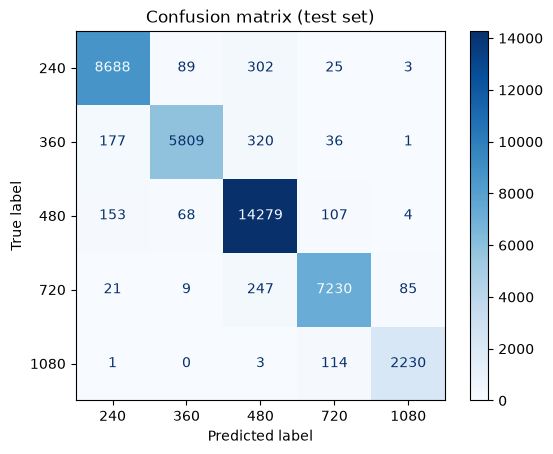

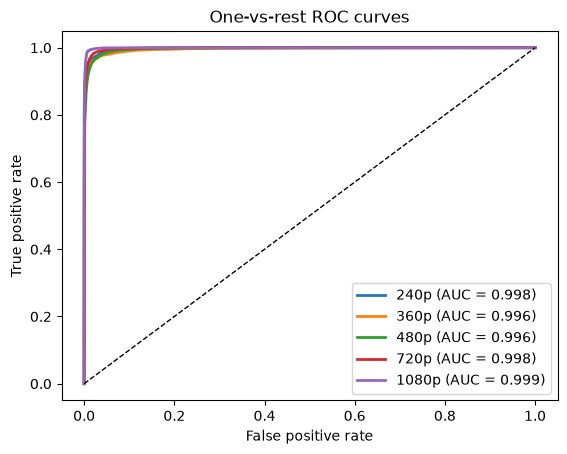

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             ConfusionMatrixDisplay, roc_curve, auc)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# 1. Accuracy
print("accuracy:     ", round(accuracy_score(y_test, y_pred), 4))
# 2. F1 -- macro averages the per-class scores, so it is not dominated by the common classes
print("f1 (macro):   ", round(f1_score(y_test, y_pred, average="macro"), 4))
print("f1 (weighted):", round(f1_score(y_test, y_pred, average="weighted"), 4))
# 4. ROC/AUC -- one-vs-rest, since this is a 5-class problem
print("ROC AUC (OvR):", round(roc_auc_score(y_test, y_prob, multi_class="ovr"), 4))

# 3. Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion matrix (test set)")
plt.show()

# 4. ROC curve per resolution (one-vs-rest)
fig, ax = plt.subplots()
for i, res in enumerate(model.classes_):
    fpr, tpr, _ = roc_curve(y_test == res, y_prob[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"{res}p (AUC = {auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("One-vs-rest ROC curves")
ax.legend(loc="lower right")
plt.show()


## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

The provided `netflix_session.pkl` is broken (see *Set Aside One Session for Part 3* above), so the "preprocessed session" here is `holdout`: one complete Netflix session removed from the dataset before training. It is in the same format the provided file would have been, with the bonus that it carries the true resolution for every window, so the plot can show predicted against actual.

session 1271251554017ecbb0e8ba991ce1548c: 59 windows of 10 s
accuracy on this session: 0.7288
f1 (macro):               0.4496


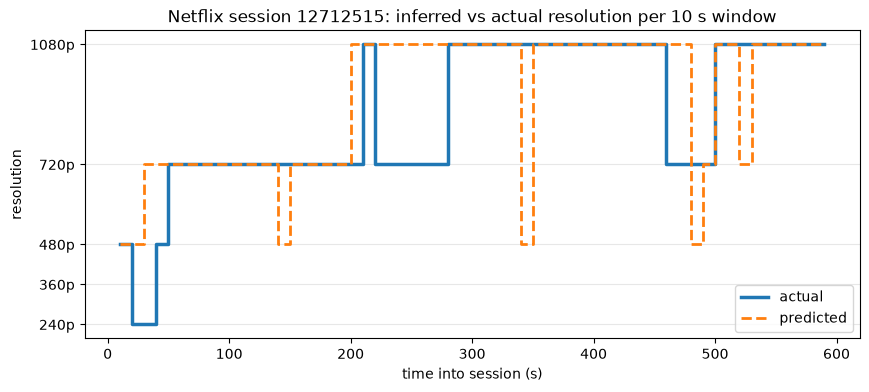

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Select exactly the columns the model was trained on, in the same order. Indexing by
# X.columns is the guard against silently passing a column that was dropped in Part 2.
X_session = holdout[X.columns]
y_session = holdout["resolution"].astype(int).to_numpy()
t = holdout["relative_timestamp"].to_numpy()

y_hat = model.predict(X_session)

print(f"session {HOLDOUT_ID}: {len(holdout)} windows of 10 s")
print("accuracy on this session:", round(accuracy_score(y_session, y_hat), 4))
print("f1 (macro):              ", round(f1_score(y_session, y_hat, average="macro"), 4))

# Resolution is a step function of time: each window holds one value until the next
# window starts, which is what where="post" draws.
fig, ax = plt.subplots(figsize=(10, 4))
ax.step(t, y_session, where="post", lw=2.5, label="actual")
ax.step(t, y_hat, where="post", lw=2, ls="--", label="predicted")
ax.set_yticks(VALID_RESOLUTIONS)
ax.set_yticklabels([f"{r}p" for r in VALID_RESOLUTIONS])
ax.set_xlabel("time into session (s)")
ax.set_ylabel("resolution")
ax.set_title(f"Netflix session {HOLDOUT_ID[:8]}: inferred vs actual resolution per 10 s window")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.show()

**Discussion**

The model gets 43 of the 59 windows right (72.9% accuracy) on a session it haven't seen during training, compared with 95.5% on the Part 2 test set. The macro F1 of 0.45 looks much worse than the accuracy because this session contains only two windows of 240p, both missed, and no 360p at all. Macro F1 gives those classes the same weight as the 1080p class that dominates the session, so two misses cost as much as a quarter of the score.

The gap between 95.5% and 72.9% is the more important result. Consecutive 10-second windows of one session looks nearly identical because they ran on the same server, same bandwidth cap, same title. A random train-test split scatters those near-duplicate windows across both sides, so the Part 2 test set contains windows whose siblings the model trained on. That score measures memorization as much as generalization. A whole unseen session is the true test, and the actual (or I guess honest) number is about 73%.